📊 Day 13 — Model Comparison
1. Goal

The goal is to determine which model performs best for predicting student Pass/Fail.

We should compare more than accuracy:

Accuracy
Precision
Recall
F1-score
Training accuracy
Testing accuracy

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")

print("Shape:", df.shape)
df.head()

Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
#Create Pass/Fail Target
median_score = df["Exam_Score"].median()

df["Pass"] = (
    df["Exam_Score"] >= median_score
).astype(int)

print("Median Score:", median_score)
print(df["Pass"].value_counts())

Median Score: 67.0
Pass
1    3725
0    2882
Name: count, dtype: int64


In [4]:
#Select Features
X = df[
    [
        "Hours_Studied",
        "Attendance",
        "Previous_Scores",
        "Sleep_Hours",
        "Tutoring_Sessions",
        "Physical_Activity"
    ]
]

y = df["Pass"]

In [5]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
#Decision Tree
decision_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

decision_tree.fit(X_train, y_train)

dt_pred = decision_tree.predict(X_test)

In [7]:
#Naive Bayes
naive_bayes = GaussianNB()

naive_bayes.fit(X_train, y_train)

nb_pred = naive_bayes.predict(X_test)

In [8]:
#Random Forest
random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)

In [9]:
#Create Comparison Table
results = []

models = {
    "Decision Tree": (decision_tree, dt_pred),
    "Naive Bayes": (naive_bayes, nb_pred),
    "Random Forest": (random_forest, rf_pred)
}

for name, (model, predictions) in models.items():

    results.append({
        "Model": name,
        "Training Accuracy": model.score(X_train, y_train),
        "Testing Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.852791,0.822239,0.825255,0.868456,0.846305
1,Naive Bayes,0.852791,0.846445,0.845663,0.889933,0.867233
2,Random Forest,0.870199,0.847958,0.840000,0.902013,0.869903


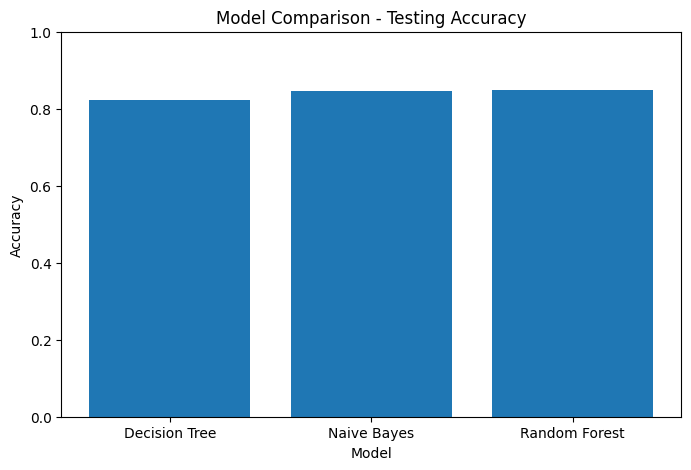

In [10]:
#Compare Testing Accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Testing Accuracy"]
)

plt.title("Model Comparison - Testing Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

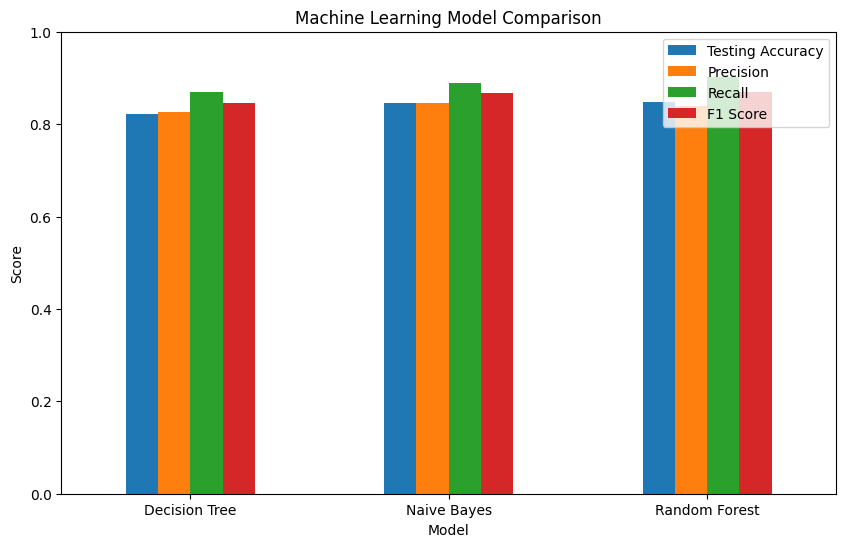

In [11]:
#Compare All Metrics
metrics = [
    "Testing Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend()

plt.show()

In [12]:
#Find the Best Model

best_model = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model                Random Forest
Training Accuracy         0.870199
Testing Accuracy          0.847958
Precision                     0.84
Recall                    0.902013
F1 Score                  0.869903
Name: 2, dtype: object


Why F1-score?

Accuracy alone can sometimes be misleading.

F1-score combines:

Precision
Recall

into one metric.

F1=2×
Precision+Recall
Precision×Recall
	​


A higher F1-score generally means a better balance between precision and recall.

| Feature                    | Decision Tree | Naive Bayes                 | Random Forest |
| -------------------------- | ------------- | --------------------------- | ------------- |
| Type                       | Tree-based    | Probabilistic               | Ensemble      |
| Number of trees            | 1             | 0                           | Many          |
| Easy to interpret          | ⭐⭐⭐           | ⭐⭐⭐                         | ⭐⭐            |
| Handles nonlinear patterns | Yes           | Limited                     | Yes           |
| Overfitting risk           | Higher        | Lower                       | Lower         |
| Feature scaling            | Not required  | Not required here           | Not required  |
| Training speed             | Fast          | Very fast                   | Slower        |
| Feature importance         | Yes           | No standard tree importance | Yes           |


"How did you select the best model?"

You can answer:

"I trained Decision Tree, Gaussian Naive Bayes, and Random Forest models on the same training and testing data. I compared their testing accuracy, precision, recall, and F1-score rather than relying only on accuracy. I selected the model based on the evaluation metric most appropriate for the classification objective."